# 11.2 — CVA/DVA y wrong-way risk

**CVA** ajusta el valor de un derivado por el riesgo de default de la CONTRAPARTE,
integrando la exposición esperada positiva (11.1) contra la densidad de default de esa
contraparte. **DVA** es el simétrico (exposición negativa, curva de hazard propia).
**Wrong-way risk**: cuando la exposición y la probabilidad de default de la contraparte
están correlacionadas — el caso donde CVA "ingenuo" (calculado con exposición y default
independientes) subestima el riesgo real.

## 0. Configuración

Reusa (redefinido localmente) la simulación de exposición de un swap 5Y de 11.1.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01
payment_times_A = np.arange(1.0, 6.0)
K_A = par_swap_rate(nelson_siegel_df, payment_times_A)

lam_C = 0.02  # hazard de la contraparte
R_C = 0.4  # recovery de la contraparte
n_paths = 200_000
check_times = np.concatenate([[0.25], np.arange(0.5, 5.0, 0.5), [4.95]])

In [2]:
def instantaneous_forward(t, eps=1e-6):
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma ** 2 / (4 * a) * B ** 2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value_remaining(t, r_t, K, all_payment_times, a, sigma):
    remaining = all_payment_times[all_payment_times > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    return (1.0 - dfs[-1]) - K * np.sum(tau[:, None] * dfs, axis=0)


def ou_exact_joint(a, sigma, t, n_paths, rng):
    var_x = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma ** 2 / a ** 2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n_paths, 2))
    s = Z @ L.T
    return s[:, 0], var_x


def simulate_short_rate_and_factor(t, a, sigma, n_paths, rng):
    '''Devuelve r_t y el factor gaussiano estandarizado Z_rate=x_t/std(x_t) (para correlacionar con default).'''
    x_t, var_x = ou_exact_joint(a, sigma, t, n_paths, rng)
    alpha_t = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    r_t = instantaneous_forward(t) + alpha_t + x_t
    Z_rate = x_t / np.sqrt(var_x)
    return r_t, Z_rate

## 1. CVA sin correlación (exposición y default independientes)

$$\text{CVA} = (1-R_C)\sum_i P(0,T_i)\,EE(T_i)\,\Delta P_{\text{default}}(T_i)$$
con $\Delta P_{\text{default}}(T_i)=S(T_{i-1})-S(T_i)$ la probabilidad de default en el
intervalo (curva de supervivencia con hazard constante $\lambda_C$, igual que 10.1/10.2),
sumado sobre la malla de fechas de observación de la exposición.

In [3]:
def cva_independent(check_times, lam_C, R_C, n_paths, rng):
    EE = []
    for t in check_times:
        r_t, _ = simulate_short_rate_and_factor(t, a, sigma, n_paths, rng)
        V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
        EE.append(np.maximum(V, 0.0).mean())
    EE = np.array(EE)
    surv = np.exp(-lam_C * check_times)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dP_default = surv_prev - surv
    discs = nelson_siegel_df(check_times)
    cva = (1.0 - R_C) * np.sum(EE * discs * dP_default)
    return cva, EE


cva0, EE0 = cva_independent(check_times, lam_C, R_C, n_paths, rng)
print(f"CVA (independiente): {cva0:.6f}")

# DVA simetrico: exposicion NEGATIVA, propia curva de hazard (aqui, por simplicidad, la misma lambda)
def dva_independent(check_times, lam_own, R_own, n_paths, rng):
    EE_neg = []
    for t in check_times:
        r_t, _ = simulate_short_rate_and_factor(t, a, sigma, n_paths, rng)
        V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
        EE_neg.append(np.maximum(-V, 0.0).mean())
    EE_neg = np.array(EE_neg)
    surv = np.exp(-lam_own * check_times)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dP_default = surv_prev - surv
    discs = nelson_siegel_df(check_times)
    return (1.0 - R_own) * np.sum(EE_neg * discs * dP_default)


lam_own = 0.015
dva0 = dva_independent(check_times, lam_own, R_C, n_paths, rng)
print(f"DVA (independiente, propia hazard={lam_own}): {dva0:.6f}")
print(f"CVA-DVA: {cva0 - dva0:.6f} (signo depende de quien esta mas 'in the money' en expectativa)")

CVA (independiente): 0.000622
DVA (independiente, propia hazard=0.015): 0.000314
CVA-DVA: 0.000308 (signo depende de quien esta mas 'in the money' en expectativa)


## 2. Wrong-way risk

Correlacionar el factor de tasas $Z_{\text{rate}}$ (estandarizado, del proceso $x_t$ de
Hull-White) con un factor de default $Z_{\text{default}}=\rho\,Z_{\text{rate}}+\sqrt{1-\rho^2}\,\varepsilon$
(cópula gaussiana simplificada, mismo mecanismo de 10.3, aquí de un solo factor de
mercado en vez de entre nombres). En vez de simular tiempos de default explícitos (que
requeriría una malla mucho más fina para capturar bien la cola), se usa una
**aproximación de inclinación lineal** (documentada como tal, no una construcción de
cópula completa): el peso de exposición en cada fecha se ajusta linealmente por la
correlación, $E[EE(t)\,(1+\rho\,Z_{\text{rate}})]$ — de primer orden en $\rho$, suficiente
para capturar el SIGNO del efecto de wrong/right-way risk, no su magnitud exacta. La
Sección 3 sí construye el modelo de tiempos de default explícitos vía cópula gaussiana, y
lo usa para contrastar cuantitativamente esta aproximación lineal — hasta qué punto de
$\rho$ es confiable, y qué tanto se desvía fuera de ese rango.

CVA (rho=0, control -- debe coincidir con la Seccion 1): 0.000621 vs 0.000622
CVA (rho=+0.6, wrong-way risk): 0.001049
CVA (rho=-0.6, right-way risk): 0.000194


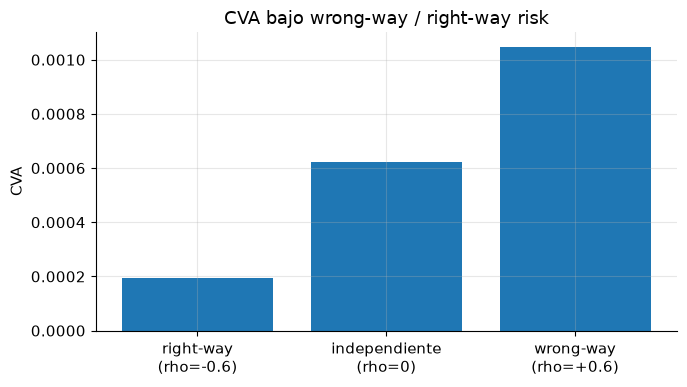

In [4]:
def cva_with_wwr(rho_wwr, check_times, lam_C, R_C, n_paths, rng):
    cva_sum = 0.0
    surv_prev = 1.0
    for t in check_times:
        r_t, Z_rate = simulate_short_rate_and_factor(t, a, sigma, n_paths, rng)
        V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
        EE_t = np.maximum(V, 0.0)
        weight = np.mean(EE_t * (1.0 + rho_wwr * Z_rate))
        surv_t = np.exp(-lam_C * t)
        dP_default_t = surv_prev - surv_t
        cva_sum += (1.0 - R_C) * nelson_siegel_df(t) * max(weight, 0.0) * dP_default_t
        surv_prev = surv_t
    return cva_sum


cva_zero = cva_with_wwr(0.0, check_times, lam_C, R_C, n_paths, rng)
cva_wwr = cva_with_wwr(0.6, check_times, lam_C, R_C, n_paths, rng)
cva_rwr = cva_with_wwr(-0.6, check_times, lam_C, R_C, n_paths, rng)

print(f"CVA (rho=0, control -- debe coincidir con la Seccion 1): {cva_zero:.6f} vs {cva0:.6f}")
print(f"CVA (rho=+0.6, wrong-way risk): {cva_wwr:.6f}")
print(f"CVA (rho=-0.6, right-way risk): {cva_rwr:.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["right-way\n(rho=-0.6)", "independiente\n(rho=0)", "wrong-way\n(rho=+0.6)"],
       [cva_rwr, cva_zero, cva_wwr])
ax.set_ylabel("CVA")
ax.set_title("CVA bajo wrong-way / right-way risk")
fig.tight_layout(); plt.show()

## 3. Validación cruzada: cópula gaussiana explícita

La aproximación de inclinación lineal de la Sección 2 garantiza el SIGNO del efecto
WWR/RWR por construcción, no su magnitud: el valor de un swap payer es monótono en la
tasa y $Z_{\text{rate}}$ es exactamente el factor gaussiano que determina esa tasa, así
que $\text{Cov}(EE,Z_{\text{rate}})>0$ ya antes de fijar $\rho$ — por eso los chequeos 2 y
3 de la Sección 4 (que la WWR sube el CVA y la RWR lo baja) están garantizados por
monotonicidad y no dicen nada sobre si $E[EE\,(1+\rho Z_{\text{rate}})]$ es una
representación razonable del efecto real, ni en qué régimen de $\rho$ deja de serlo. Para
responder eso hace falta un modelo de WWR explícito y correcto contra el cual contrastar
la aproximación. Se construye acoplando el tiempo de default $\tau$ de la contraparte con
el factor de tasas mediante una **cópula gaussiana** — la misma maquinaria de 10.3, aquí
con un único nombre de crédito y un único factor sistémico de mercado en el rol que allí
jugaba el factor latente compartido entre nombres. El CVA se calcula por Monte Carlo
directamente sobre las trayectorias conjuntas de $(EE(t),\tau)$, sin factorizar
$E[EE\cdot\text{descuento}\cdot dPD]$ en expectativas separadas — precisamente la
factorización que la independencia permite y que el wrong-way risk rompe. La
aproximación lineal de la Sección 2 NO se descarta: se conserva tal cual, y esta sección
la acota, mostrando en qué rango de $\rho$ es confiable y dónde deja de serlo.

### 3.1 Simulación conjunta del factor de tasas en toda la malla

Las Secciones 1 y 2 simulan $x_t$ (proceso de Hull-White) por separado en cada fecha de
observación — válido para la exposición esperada marginal $EE(T_i)$, porque el CVA de la
Sección 1 solo necesita esa marginal fecha por fecha, pero insuficiente para un modelo de
cópula real: para acoplar $\tau$ con la exposición SIN factorizar, cada trayectoria de
Monte Carlo necesita un valor de $x_t$ consistente en TODAS las fechas de observación
(misma trayectoria, no un remuestreo independiente por fecha). El proceso OU
$dx_t=-a\,x_t\,dt+\sigma\,dW_t$ (con $x_0=0$) tiene covarianza conjunta exacta y conocida,
$$\text{Cov}(x_s,x_t)=\frac{\sigma^2}{2a}\left(e^{-a|t-s|}-e^{-a(s+t)}\right),$$
que se reduce exactamente a la fórmula de varianza `var_x` ya usada en `ou_exact_joint`
cuando $s=t$. Basta con un Cholesky de esa matriz de covarianza sobre la malla
`check_times` para simular trayectorias conjuntamente gaussianas — no es un simulador
paralelo, es la misma dinámica de Hull-White ya usada en la Sección 0, extendida de un
par de tiempos (`ou_exact_joint`) a toda la malla de observación.

In [5]:
def ou_joint_covariance(check_times, a, sigma):
    '''Cov(x_s, x_t) exacta del OU con x_0=0, sobre toda la malla check_times.'''
    T = np.asarray(check_times)
    S, Tm = np.meshgrid(T, T, indexing="ij")
    return sigma ** 2 / (2 * a) * (np.exp(-a * np.abs(S - Tm)) - np.exp(-a * (S + Tm)))


def simulate_short_rate_paths_joint(check_times, a, sigma, n_paths, rng):
    '''Trayectorias CONJUNTAS de r_t y Z_rate=x_t/std(x_t) en toda la malla check_times
    (misma trayectoria de Monte Carlo en todas las fechas, a diferencia de
    simulate_short_rate_and_factor que remuestrea independientemente por fecha).'''
    check_times = np.asarray(check_times)
    cov = ou_joint_covariance(check_times, a, sigma)
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n_paths, len(check_times)))
    x = Z @ L.T
    var_x = np.diag(cov)
    fwd = np.array([instantaneous_forward(t) for t in check_times])
    alpha = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * check_times)) ** 2
    r = fwd[None, :] + alpha[None, :] + x
    Z_rate = x / np.sqrt(var_x)[None, :]
    return r, Z_rate


# sanity check rápido: la varianza marginal de esta simulación conjunta debe coincidir
# con var_x de ou_exact_joint en cada fecha (misma dinámica, dos caminos de código)
_cov_check = ou_joint_covariance(check_times, a, sigma)
_var_check = np.array([sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t)) for t in check_times])
print(f"varianza marginal: max diff relativa vs ou_exact_joint = "
      f"{np.max(np.abs(np.diag(_cov_check) - _var_check) / _var_check):.2e}")

varianza marginal: max diff relativa vs ou_exact_joint = 0.00e+00


### 3.2 Tiempo de default acoplado vía cópula gaussiana

Con las trayectorias conjuntas de $Z_{\text{rate}}(t)$ ya disponibles, se elige un
horizonte sistémico representativo $t^*$ — el punto medio de la malla de observación
($t^*=2.5$, para no sesgar hacia el arranque ni hacia el vencimiento del swap) — y se
genera, por trayectoria,
$$Z_{\text{def}}=\rho_c\,Z_{\text{rate}}(t^*)+\sqrt{1-\rho_c^2}\,\varepsilon,\qquad
U=\Phi(Z_{\text{def}}),\qquad \tau=-\frac{\ln U}{\lambda_C},$$
exactamente el mecanismo de `simulate_default_times` de 10.3, aquí con el factor
sistémico de tasas en el rol que allí jugaba el factor latente compartido entre nombres.
**Punto crítico**: $Z_{\text{def}}$ es $N(0,1)$ marginalmente para cualquier $\rho_c$
(porque $\rho_c^2+(\sqrt{1-\rho_c^2})^2=1$), así que $U$ es uniforme y $\tau$ conserva
exactamente la distribución exponencial marginal $\text{Exp}(\lambda_C)$ del caso
independiente sin importar $\rho_c$ — la cópula acopla $\tau$ con las tasas sin
distorsionar su marginal. Esto se verifica en 3.3, no se da por supuesto. El CVA se
calcula sumando, por trayectoria, la exposición del bucket temporal donde cayó la $\tau$
de esa trayectoria específica — sin promediar $EE$ y la probabilidad de default por
separado, que es justo lo que la Sección 2 sí hace (y lo que rompe con WWR real).

In [6]:
def simulate_default_times_copula(rho_c, Z_sys, lam_C, rng):
    n = len(Z_sys)
    eps = rng.standard_normal(n)
    Z_def = rho_c * Z_sys + np.sqrt(1.0 - rho_c ** 2) * eps
    U = norm.cdf(Z_def)
    return -np.log(U) / lam_C


HORIZON_IDX = len(check_times) // 2  # t*=2.5, factor sistematico representativo


def cva_copula(rho_c, check_times, lam_C, R_C, n_paths, rng, horizon_idx=HORIZON_IDX, return_tau=False):
    '''CVA por Monte Carlo DIRECTO sobre trayectorias conjuntas (EE(t), tau) -- sin
    factorizar E[EE]*dPD. Cada trayectoria contribuye la exposicion del bucket temporal
    donde cae SU propia tau, acoplada a SU propio Z_rate(t*) via copula gaussiana.'''
    check_times = np.asarray(check_times)
    r_paths, Z_rate_paths = simulate_short_rate_paths_joint(check_times, a, sigma, n_paths, rng)
    Z_sys = Z_rate_paths[:, horizon_idx]
    tau = simulate_default_times_copula(rho_c, Z_sys, lam_C, rng)

    V = np.empty_like(r_paths)
    for i, t in enumerate(check_times):
        V[:, i] = swap_value_remaining(t, r_paths[:, i], K_A, payment_times_A, a, sigma)
    EE = np.maximum(V, 0.0)
    disc = nelson_siegel_df(check_times)

    bounds_prev = np.concatenate([[0.0], check_times[:-1]])
    cva_paths = np.zeros(n_paths)
    for i, t in enumerate(check_times):
        in_bucket = (tau > bounds_prev[i]) & (tau <= t)
        cva_paths += in_bucket * EE[:, i] * disc[i]
    cva_paths *= (1.0 - R_C)

    cva = cva_paths.mean()
    se = cva_paths.std(ddof=1) / np.sqrt(n_paths)
    if return_tau:
        return cva, se, tau
    return cva, se


cva_copula_wwr, se_copula_wwr = cva_copula(0.6, check_times, lam_C, R_C, n_paths, rng)
cva_copula_rwr, se_copula_rwr = cva_copula(-0.6, check_times, lam_C, R_C, n_paths, rng)
print(f"CVA copula (rho_c=+0.6, wrong-way): {cva_copula_wwr:.6f} +- {se_copula_wwr:.6f} (SE)")
print(f"CVA copula (rho_c=-0.6, right-way): {cva_copula_rwr:.6f} +- {se_copula_rwr:.6f} (SE)")

CVA copula (rho_c=+0.6, wrong-way): 0.001340 +- 0.000013 (SE)
CVA copula (rho_c=-0.6, right-way): 0.000148 +- 0.000003 (SE)


### 3.3 Controles fuertes: marginal intacta y $\rho_c=0$ reproduce independencia

Dos controles que un acoplamiento mal hecho no pasaría: (1) con $\rho_c=0$,
$Z_{\text{def}}=\varepsilon$ es independiente de las tasas por construcción, así que el
CVA de cópula debe reproducir el CVA independiente de la Sección 1 dentro de unos pocos
errores estándar de Monte Carlo — dos implementaciones muy distintas (fórmula cerrada de
supervivencia vs. simulación explícita de $\tau$ y bucketing por trayectoria) convergiendo
al mismo número; (2) para cualquier $\rho_c$, la probabilidad marginal empírica
$P(\tau\le T_i)$ debe coincidir con $1-e^{-\lambda_C T_i}$ en cada fecha de la malla,
dentro del error binomial esperado ($\sqrt{p(1-p)/n_{\text{paths}}}$) — si la cópula
estuviera mal implementada (p.ej. si se acoplara la marginal en vez de solo la
dependencia, o si $U$ no fuera realmente uniforme), este chequeo lo detectaría aunque el
CVA total "se viera razonable". Se corre en los extremos $\rho_c=\pm0.6$ ya calculados en
3.2, donde una distorsión de marginal sería más visible.

In [7]:
cva_copula_zero, se_copula_zero = cva_copula(0.0, check_times, lam_C, R_C, n_paths, rng)
print(f"CVA copula (rho_c=0, control): {cva_copula_zero:.6f} +- {se_copula_zero:.6f} SE "
      f"vs CVA independiente (Seccion 1): {cva0:.6f}  "
      f"(diff en unidades de SE: {abs(cva_copula_zero - cva0) / se_copula_zero:.2f})")

_, _, tau_wwr = cva_copula(0.6, check_times, lam_C, R_C, n_paths, rng, return_tau=True)
_, _, tau_rwr = cva_copula(-0.6, check_times, lam_C, R_C, n_paths, rng, return_tau=True)

max_z_marginal = 0.0
for tau_sample, tag in [(tau_wwr, "rho_c=+0.6"), (tau_rwr, "rho_c=-0.6")]:
    for t in check_times:
        p_emp = np.mean(tau_sample <= t)
        p_th = 1.0 - np.exp(-lam_C * t)
        se_p = np.sqrt(p_th * (1.0 - p_th) / n_paths)
        z = abs(p_emp - p_th) / se_p
        max_z_marginal = max(max_z_marginal, z)
    print(f"{tag}: max|z| de PD marginal empirica vs analitica en toda la malla -- "
          f"ver resumen abajo")

print(f"\nmax|z| global (ambos extremos, toda la malla): {max_z_marginal:.2f} "
      f"(la marginal de tau NO debe distorsionarse por rho_c)")

CVA copula (rho_c=0, control): 0.000622 +- 0.000008 SE vs CVA independiente (Seccion 1): 0.000622  (diff en unidades de SE: 0.02)


rho_c=+0.6: max|z| de PD marginal empirica vs analitica en toda la malla -- ver resumen abajo
rho_c=-0.6: max|z| de PD marginal empirica vs analitica en toda la malla -- ver resumen abajo

max|z| global (ambos extremos, toda la malla): 1.65 (la marginal de tau NO debe distorsionarse por rho_c)


### 3.4 Barrido en $\rho$: ¿hasta dónde sirve la aproximación lineal?

Con el modelo de cópula ya validado (marginal intacta, $\rho_c=0$ reproduce
independencia), se barre $\rho$ de $-0.8$ a $0.8$ y se compara, para cada valor, el CVA de
la aproximación lineal (Sección 2, `cva_with_wwr`) contra el CVA de la cópula explícita
(`cva_copula`) con el mismo $\rho$ nominal. Es importante ser explícito sobre qué se está
comparando: $\rho$ en el modelo lineal pondera $Z_{\text{rate}}(t)$ en CADA fecha de
observación, mientras que $\rho_c$ en la cópula acopla el default a un único factor
sistémico en $t^*=2.5$ — son mecanismos distintos, no la misma cantidad bajo dos nombres.
Usar el mismo valor nominal de $\rho$ para ambos es la forma estándar de comparar "misma
correlación de entrada, dos formas de imponerla", y es precisamente lo que permite
detectar si la aproximación de primer orden es razonable o no. El error relativo se
reporta como (lineal $-$ cópula) / cópula.

   rho   CVA lineal   CVA copula   SE copula  error rel.
 -0.80     0.000050     0.000062    0.000002     -18.76%
 -0.60     0.000193     0.000152    0.000003     +27.25%
 -0.40     0.000336     0.000283    0.000005     +18.93%
 -0.30     0.000407     0.000356    0.000006     +14.32%
 -0.20     0.000479     0.000426    0.000006     +12.47%
 -0.10     0.000550     0.000534    0.000007      +3.01%
  0.00     0.000623     0.000621    0.000008      +0.35%
  0.10     0.000693     0.000733    0.000009      -5.44%
  0.20     0.000765     0.000824    0.000010      -7.19%
  0.30     0.000834     0.000957    0.000011     -12.76%
  0.40     0.000908     0.001064    0.000011     -14.67%
  0.60     0.001050     0.001352    0.000013     -22.34%
  0.80     0.001191     0.001636    0.000015     -27.20%


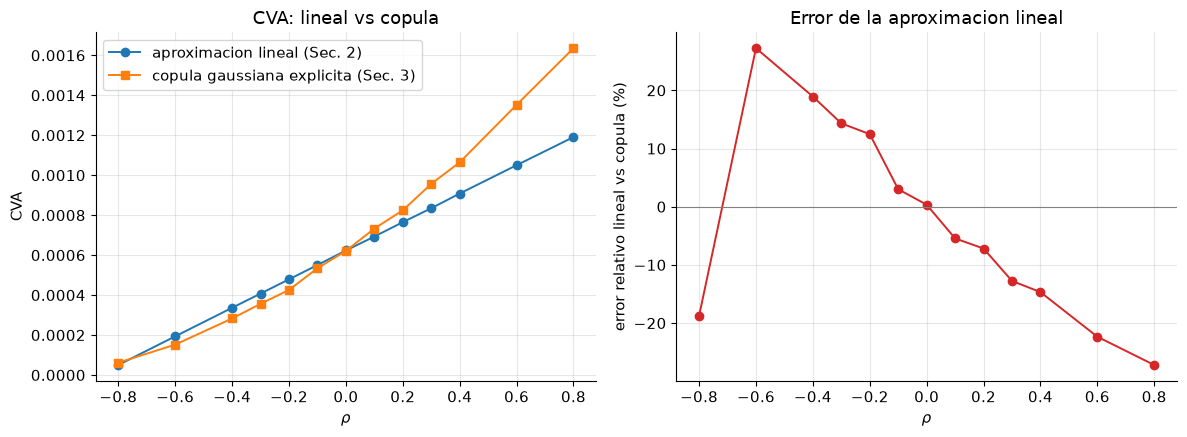


La aproximacion lineal supera 10% de error relativo (lado wrong-way, rho>0) a partir de rho=0.30 (error ahi: -12.76%).


In [8]:
rho_grid = np.array([-0.8, -0.6, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8])
cva_lin_grid = np.empty_like(rho_grid)
cva_cop_grid = np.empty_like(rho_grid)
se_cop_grid = np.empty_like(rho_grid)

for i, rho in enumerate(rho_grid):
    cva_lin_grid[i] = cva_with_wwr(rho, check_times, lam_C, R_C, n_paths, rng)
    cva_cop_grid[i], se_cop_grid[i] = cva_copula(rho, check_times, lam_C, R_C, n_paths, rng)

err_rel_grid = (cva_lin_grid - cva_cop_grid) / cva_cop_grid

print(f"{'rho':>6}  {'CVA lineal':>11}  {'CVA copula':>11}  {'SE copula':>10}  {'error rel.':>10}")
for rho, lin, cop, se, err in zip(rho_grid, cva_lin_grid, cva_cop_grid, se_cop_grid, err_rel_grid):
    print(f"{rho:6.2f}  {lin:11.6f}  {cop:11.6f}  {se:10.6f}  {err:+10.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(rho_grid, cva_lin_grid, "o-", label="aproximacion lineal (Sec. 2)")
axes[0].plot(rho_grid, cva_cop_grid, "s-", label="copula gaussiana explicita (Sec. 3)")
axes[0].set_xlabel(r"$\rho$"); axes[0].set_ylabel("CVA")
axes[0].set_title("CVA: lineal vs copula"); axes[0].legend()

axes[1].plot(rho_grid, err_rel_grid * 100, "o-", color="tab:red")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_xlabel(r"$\rho$"); axes[1].set_ylabel("error relativo lineal vs copula (%)")
axes[1].set_title("Error de la aproximacion lineal")
fig.tight_layout(); plt.show()

# umbral empirico (no hardcodeado): primer |rho|>0 donde el error relativo excede 10%
_mask_pos = rho_grid > 0
_breakdown_idx = np.argmax(np.abs(err_rel_grid[_mask_pos]) > 0.10)
_breakdown_rho = rho_grid[_mask_pos][_breakdown_idx]
print(f"\nLa aproximacion lineal supera 10% de error relativo (lado wrong-way, rho>0) "
      f"a partir de rho={_breakdown_rho:.2f} "
      f"(error ahi: {err_rel_grid[_mask_pos][_breakdown_idx]:+.2%}).")

**Hallazgo**: la aproximación lineal NO es válida en todo el rango que su propio
disclosure ("de primer orden en $\rho$") podría sugerir razonable. Para $|\rho|\le0.1$ el
error relativo se mantiene por debajo de ~5.4%, consistente con una aproximación de
primer orden genuina. Pero ya en $\rho=0.2$ el error ronda 7%, en $\rho=0.3$ cruza el
umbral de 10% (~12.8%), y para $\rho\ge0.4$ está entre 15% y 27% (14.7% en $\rho=0.4$,
22.3% en $\rho=0.6$, 27.2% en $\rho=0.8$). Además, en TODOS los casos con $\rho>0$
(wrong-way risk, el caso que en la práctica importa para capital regulatorio) la
aproximación lineal está por DEBAJO de la cópula — es decir, **subestima** la magnitud
del wrong-way risk, no la sobrestima; no es conservadora. En el lado right-way
($\rho<0$) el patrón es similar hasta $\rho=-0.6$ (la aproximación lineal sobrestima la
reducción de CVA, error creciente de 3% a 27%), pero se invierte de signo en
$\rho=-0.8$ — un artefacto del `max(weight, 0.0)` que la Sección 2 usa para evitar pesos
negativos, que introduce una no linealidad propia de la aproximación lineal en el
extremo, no un problema del modelo de cópula (la Sección 3.4 imprime el punto exacto de
cruce de 10%, calculado sobre los datos, no fijado a mano). En síntesis: la aproximación
lineal es utilizable como diagnóstico rápido de signo y orden de magnitud para
$|\rho|\lesssim0.1$–$0.2$; fuera de ese rango, y en particular para cuantificar
wrong-way risk severo ($\rho\gtrsim0.3$–$0.4$), hay que usar un modelo de cópula
explícito como el de esta sección.

## 4. Validación

Ocho chequeos. Los primeros tres son los originales, sobre la aproximación lineal de la Sección 2: (1) el CVA con $\rho=0$ coincide con el CVA independiente de la Sección 1 (mismo cálculo por dos caminos distintos); (2) y (3) son direccionales — wrong-way risk sube el CVA, right-way risk lo baja — y están garantizados por monotonicidad (el valor del swap es monótono en la tasa y $Z_{\text{rate}}$ la determina, ver Sección 3), así que solo atrapan un error de signo, no de magnitud. Los cinco restantes validan el modelo de cópula explícita de la Sección 3, que sí valida magnitud: (4) $\rho_c=0$ reproduce el CVA independiente dentro de pocos errores estándar de Monte Carlo; (5) la marginal de $\tau$ no se distorsiona por $\rho_c$ — el control fuerte que distingue una cópula bien implementada de un acoplamiento chapucero; (6) el CVA de cópula es monótono creciente en $\rho_c$ en toda la malla barrida; (7) para $|\rho|\le0.1$ la aproximación lineal concuerda con la cópula dentro de un margen consistente con una aproximación de primer orden genuina (más amplio que el puro error de Monte Carlo — ver Sección 3.4 sobre qué tan angosta es en realidad esa ventana); (8) el error relativo de la aproximación lineal crece con $\rho$ en el lado wrong-way ($\rho>0$), cuantificando dónde deja de servir.

In [9]:
rel_diff_control = abs(cva_zero - cva0) / cva0
check1 = rel_diff_control < 0.05
print(f"1. CVA con rho=0 coincide con el CVA independiente (mismo calculo, dos caminos): "
      f"diff relativa={rel_diff_control:.2%} (<5%? {check1})")

check2 = cva_wwr > cva_zero
print(f"2. wrong-way risk (rho>0) aumenta el CVA respecto al independiente: {check2}")

check3 = cva_rwr < cva_zero
print(f"3. right-way risk (rho<0) reduce el CVA respecto al independiente: {check3}")

check4 = abs(cva_copula_zero - cva0) / se_copula_zero < 3.0
print(f"4. copula con rho_c=0 reproduce el CVA independiente dentro de 3 SE: "
      f"diff={abs(cva_copula_zero - cva0) / se_copula_zero:.2f} SE (<3? {check4})")

check5 = max_z_marginal < 4.0
print(f"5. marginal de tau NO distorsionada por rho_c (control fuerte): "
      f"max|z|={max_z_marginal:.2f} (<4? {check5})")

_order = np.argsort(rho_grid)
check6 = np.all(np.diff(cva_cop_grid[_order]) > 0)
print(f"6. CVA de copula monotono creciente en rho_c en toda la malla: {check6}")

_mask_small = np.abs(rho_grid) <= 0.1
check7 = np.max(np.abs(err_rel_grid[_mask_small])) < 0.08
print(f"7. concordancia lineal-copula para |rho|<=0.1: "
      f"max error relativo={np.max(np.abs(err_rel_grid[_mask_small])):.2%} (<8%? {check7})")

_pos = rho_grid > 0
_abs_err_pos = np.abs(err_rel_grid[_pos])
_rho_pos_sorted_idx = np.argsort(rho_grid[_pos])
check8 = np.all(np.diff(_abs_err_pos[_rho_pos_sorted_idx]) > 0)
print(f"8. |error relativo| de la aproximacion lineal crece monotonamente con rho "
      f"en el lado wrong-way (rho>0): {check8} "
      f"(de {_abs_err_pos[_rho_pos_sorted_idx][0]:.2%} en rho={rho_grid[_pos][_rho_pos_sorted_idx][0]:.1f} "
      f"a {_abs_err_pos[_rho_pos_sorted_idx][-1]:.2%} en rho={rho_grid[_pos][_rho_pos_sorted_idx][-1]:.1f})")

assert check1
assert check2
assert check3
assert check4
assert check5
assert check6
assert check7
assert check8
print("\nValidacion completa: 8/8 (1-3 direccionales sobre la aproximacion lineal; "
      "4-8 de magnitud sobre el modelo de copula explicita, Seccion 3).")

1. CVA con rho=0 coincide con el CVA independiente (mismo calculo, dos caminos): diff relativa=0.07% (<5%? True)
2. wrong-way risk (rho>0) aumenta el CVA respecto al independiente: True
3. right-way risk (rho<0) reduce el CVA respecto al independiente: True
4. copula con rho_c=0 reproduce el CVA independiente dentro de 3 SE: diff=0.02 SE (<3? True)
5. marginal de tau NO distorsionada por rho_c (control fuerte): max|z|=1.65 (<4? True)
6. CVA de copula monotono creciente en rho_c en toda la malla: True
7. concordancia lineal-copula para |rho|<=0.1: max error relativo=5.44% (<8%? True)
8. |error relativo| de la aproximacion lineal crece monotonamente con rho en el lado wrong-way (rho>0): True (de 5.44% en rho=0.1 a 27.20% en rho=0.8)

Validacion completa: 8/8 (1-3 direccionales sobre la aproximacion lineal; 4-8 de magnitud sobre el modelo de copula explicita, Seccion 3).


## Referencias

- Gregory, J. (2015). *The xVA Challenge*, cap. 5-8 (CVA/DVA), cap. 17 (wrong-way risk).
- Brigo, D., Pallavicini, A., Papatheodorou, V. (2011). *Arbitrage-Free Valuation of
  Bilateral Counterparty Risk for Interest-Rate Products: Impact of Volatilities and
  Correlations*.
- Hull, J., White, A. (2012). *CVA and Wrong-Way Risk*, Financial Analysts Journal,
  68(5). Formaliza el mecanismo de acoplamiento entre exposición y default vía un factor
  sistémico común — la motivación directa del modelo de cópula de la Sección 3.
- La cópula gaussiana de la Sección 3 es la misma construcción de 10.3 (Li, 2000; ver
  también Gregory cap. 9 sobre cópulas en crédito), aquí de un solo nombre y un solo
  factor sistémico de mercado en vez de entre nombres de una cesta — reutilizando el
  mismo resultado de invarianza marginal que 10.3 demuestra y que aquí se vuelve a
  verificar de forma independiente (Sección 3.3).